# Patient Profile Creation

Install required packages

In [1]:
!pip install -q scikit-learn scipy

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import logging
from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy import stats

In [3]:
# Configure paths
notebook_dir = Path().resolve()
FEATURE_PATH = notebook_dir.parents[1] / "1" / "Features"

# Feature file names
FILES_CONFIG = {
    'laboratory_tests': 'laboratory_tests_features.csv',
    'procedures': 'procedure_code_features.csv',
    'heart_diagnoses': 'heart_diagnoses_features.csv',
    'microbiology': 'microbiology_events_features.csv'
}

print(f"Feature Path: {FEATURE_PATH}")
print(f"Configuration loaded")

Feature Path: /home/gabriele/DAD/project/Tasks/1/Features
Configuration loaded


In [4]:
# Load all feature tables
dfs = {}
for key, filename in FILES_CONFIG.items():
    filepath = FEATURE_PATH / filename
    dfs[key] = pd.read_csv(filepath)

In [5]:
def identify_duplicates(dfs):
    """
    Identify dataframes with hadm_id associated to multiple subject_id.
    
    Args:
        dfs (dict): Dictionary of dataframes
        
    Returns:
        dict: Dictionary with problematic dataframe names and number of duplicate hadm_id
    """
    problematic_dfs = {}
    
    for name, df in dfs.items():
        if 'hadm_id' in df.columns and 'subject_id' in df.columns:
            hadm_id_counts = df.groupby('hadm_id')['subject_id'].nunique()
            multi_subject = hadm_id_counts[hadm_id_counts > 1]
            
            if len(multi_subject) > 0:
                problematic_dfs[name] = len(multi_subject)
    
    return problematic_dfs


In [6]:
def clean_duplicate_admissions(df, df_name):
    """
    Remove rows where the same hadm_id is associated to multiple subject_id.
    
    Args:
        df (pd.DataFrame): Dataframe to clean
        df_name (str): Dataframe name (for logging)
        
    Returns:
        pd.DataFrame: Cleaned dataframe
        int: Number of removed rows
    """
    original_shape = df.shape
    
    # Filter keeping only hadm_id with a single subject_id
    df_cleaned = df.groupby('hadm_id').filter(
        lambda x: x['subject_id'].nunique() == 1
    )
    
    rows_removed = len(df) - len(df_cleaned)
    
    return df_cleaned, rows_removed

In [7]:
def clean_all_dataframes(dfs):
    """
    Automatically clean all dataframes with duplicate issues.
    
    Args:
        dfs (dict): Dictionary of dataframes
        
    Returns:
        dict: Dictionary of cleaned dataframes
        dict: Cleaning statistics
    """
    
    cleaned_dfs = dfs.copy()
    cleaning_stats = {}
    
    for name, df in dfs.items():
        if 'hadm_id' in df.columns and 'subject_id' in df.columns:
            # Check if there are issues
            hadm_id_counts = df.groupby('hadm_id')['subject_id'].nunique()
            multi_subject = hadm_id_counts[hadm_id_counts > 1]
            
            if len(multi_subject) > 0:
                df_cleaned, rows_removed = clean_duplicate_admissions(df, name)
                cleaned_dfs[name] = df_cleaned
                cleaning_stats[name] = {
                    'rows_removed': rows_removed,
                    'original_shape': df.shape,
                    'cleaned_shape': df_cleaned.shape
                }
    
    return cleaned_dfs, cleaning_stats

In [8]:
def verify_cleaning(dfs):
    """
    Verify that all dataframes have been cleaned correctly.
    
    Args:
        dfs (dict): Dictionary of dataframes to verify
        
    Returns:
        bool: True if all dataframes are clean, False otherwise
    """
    all_clean = True
    
    for name, df in dfs.items():
        if 'hadm_id' in df.columns and 'subject_id' in df.columns:
            hadm_id_counts = df.groupby('hadm_id')['subject_id'].nunique()
            multi_subject = hadm_id_counts[hadm_id_counts > 1]
            
            is_clean = len(multi_subject) == 0
            
            if not is_clean:
                all_clean = False
    
    return all_clean


In [9]:
def process_dataframes(dfs):
    """
    Main function that orchestrates the entire cleaning process.
    
    Args:
        dfs (dict): Dictionary of dataframes to process
        
    Returns:
        dict: Dictionary of cleaned dataframes
        dict: Cleaning statistics
    """
    # 1. Identify problems
    problematic_dfs = identify_duplicates(dfs)
    
    if not problematic_dfs:
        return dfs, {}
    
    # 2. Clean dataframes
    cleaned_dfs, cleaning_stats = clean_all_dataframes(dfs)
    
    # 3. Verify cleaning
    all_clean = verify_cleaning(cleaned_dfs)
    
    # 4. Final summary
    if all_clean:
        for name, stats in cleaning_stats.items():
            print(f"  {name}: -{stats['rows_removed']} rows")
    
    return cleaned_dfs, cleaning_stats

In [10]:
dfs_cleaned, stats = process_dataframes(dfs)
dfs = dfs_cleaned

## Data Merging

In [11]:
print("\nHeart Diagnoses + Microbiology")

# Merge heart diagnoses with microbiology
heart_microbiology = pd.merge(
    dfs['heart_diagnoses'],
    dfs['microbiology'],
    on=['subject_id', 'hadm_id'],
    how='outer',
    suffixes=('_heart', '_microbio')
)

print(f" Heart + Microbiology shape: {heart_microbiology.shape}")
print(f"   Unique patients: {heart_microbiology['subject_id'].nunique()}")


Heart Diagnoses + Microbiology
 Heart + Microbiology shape: (4711, 20)
   Unique patients: 4244


In [12]:
print("\nAdd Procedures")

# merge with procedures
heart_micro_procedures = pd.merge(
    heart_microbiology,
    dfs['procedures'],
    on=['subject_id', 'hadm_id'],
    how='outer',
    suffixes=('', '_proc')
)

print(f" Heart + Microbiology + Procedures shape: {heart_micro_procedures.shape}")
print(f"Unique patients: {heart_micro_procedures['subject_id'].nunique()}")


Add Procedures
 Heart + Microbiology + Procedures shape: (4746, 23)
Unique patients: 4278


In [13]:
# Merge with laboratory tests
patient_admissions = pd.merge(
    heart_micro_procedures,
    dfs['laboratory_tests'],
    on='hadm_id',
    how='outer',
    suffixes=('', '_lab')
)

patient_admissions['hadm_id'] = patient_admissions['hadm_id'].astype('Int64')

print(f"  Final merged shape: {patient_admissions.shape}")
print(f"  Unique patients: {patient_admissions['subject_id'].nunique()}")
print(f"  Total admissions: {patient_admissions['hadm_id'].nunique()}")

  Final merged shape: (4761, 35)
  Unique patients: 4278
  Total admissions: 4761


In [14]:
patient_admissions.drop_duplicates(
    subset=['subject_id', 'hadm_id'], 
    keep='first',
    inplace=True
)

print(f"  Final merged shape: {patient_admissions.shape}")
print(f"  Unique patients: {patient_admissions['subject_id'].nunique()}")
print(f"  Total admissions: {patient_admissions['hadm_id'].nunique()}")

  Final merged shape: (4761, 35)
  Unique patients: 4278
  Total admissions: 4761


In [15]:
# Conta quanti duplicati hai
n_duplicates = patient_admissions.duplicated(subset=['subject_id', 'hadm_id']).sum()
print(f"Numero di righe duplicate: {n_duplicates}")
# Dovrebbe essere: 5166 - 4761 = 405

# Visualizza esempi di duplicati
duplicated_mask = patient_admissions.duplicated(subset=['subject_id', 'hadm_id'], keep=False)
duplicated_examples = patient_admissions[duplicated_mask].sort_values(['subject_id', 'hadm_id'])
print(duplicated_examples[['subject_id', 'hadm_id']].head(10))


Numero di righe duplicate: 0
Empty DataFrame
Columns: [subject_id, hadm_id]
Index: []


In [16]:
patient_admissions.head()

,subject_id,hadm_id,age,gender,temperature,bp_systolic,bp_diastolic,heart_rate,respiratory_rate,oxygen_saturation,...,tests_days_span,k_max,k_min,k_n,creat_max,creat_n,glu_max,glu_n,glu_var,na_cl_ratio
0,12869457.0,20004456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.0,...,2.0,5.6,4.8,3.0,2.7,3.0,193.0,3.0,36.94,1.33
1,13709807.0,20007905,NaN,NaN,NaN,135.0,62.0,127.0,29.0,93.0,...,3.0,4.8,4.1,7.0,1.3,7.0,314.0,6.0,29.85,1.40
2,12002285.0,20013519,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.0,...,2.0,4.4,3.6,4.0,2.2,4.0,104.0,4.0,13.74,1.35
3,16110697.0,20013602,NaN,NaN,36.1,128.0,55.0,76.0,20.0,97.0,...,1.0,5.1,3.5,5.0,1.2,4.0,186.0,2.0,61.52,1.35
4,17171235.0,20014999,78.0,1.0,36.3,122.0,70.0,75.0,24.0,NaN,...,7.0,4.6,3.4,13.0,1.5,12.0,144.0,12.0,13.81,1.40


In [17]:
patient_admissions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4761 entries, 0 to 4760
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   subject_id                     4746 non-null   float64
 1   hadm_id                        4761 non-null   Int64  
 2   age                            1326 non-null   float64
 3   gender                         1326 non-null   float64
 4   temperature                    2341 non-null   float64
 5   bp_systolic                    2295 non-null   float64
 6   bp_diastolic                   2295 non-null   float64
 7   heart_rate                     2165 non-null   float64
 8   respiratory_rate               2094 non-null   float64
 9   oxygen_saturation              3730 non-null   float64
 10  heart_failure_severity_score   1494 non-null   float64
 11  cad_severity_score             2422 non-null   float64
 12  valvular_disease_score         4103 non-null   f

In [19]:
patient_profiles = patient_admissions.copy()

## Data Quality Assessment

### Missingness analysis

In [20]:
patient_profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4761 entries, 0 to 4760
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   subject_id                     4746 non-null   float64
 1   hadm_id                        4761 non-null   Int64  
 2   age                            1326 non-null   float64
 3   gender                         1326 non-null   float64
 4   temperature                    2341 non-null   float64
 5   bp_systolic                    2295 non-null   float64
 6   bp_diastolic                   2295 non-null   float64
 7   heart_rate                     2165 non-null   float64
 8   respiratory_rate               2094 non-null   float64
 9   oxygen_saturation              3730 non-null   float64
 10  heart_failure_severity_score   1494 non-null   float64
 11  cad_severity_score             2422 non-null   float64
 12  valvular_disease_score         4103 non-null   f

In [21]:
missing_stats = pd.DataFrame({
    'Feature': patient_profiles.columns,
    'Missing_Count': patient_profiles.isnull().sum(),
    'Missing_Pct': (patient_profiles.isnull().sum() / len(patient_profiles) * 100).round(2)
}).sort_values('Missing_Pct', ascending=False)

In [22]:
# Show top missing features
print("\nTop 15 features with missing data:")
print(missing_stats[missing_stats['Missing_Count'] > 0].head(15).to_string(index=False))


Top 15 features with missing data:
                     Feature  Missing_Count  Missing_Pct
                         age           3435        72.15
                      gender           3435        72.15
heart_failure_severity_score           3267        68.62
      ct_complications_score           3138        65.91
            respiratory_rate           2667        56.02
                  heart_rate           2596        54.53
    infection_severity_score           2563        53.83
                bp_diastolic           2466        51.80
                 bp_systolic           2466        51.80
                 temperature           2420        50.83
          cad_severity_score           2339        49.13
       ecg_abnormality_score           1624        34.11
           unique_procedures           1302        27.35
        procedures_days_span           1302        27.35
            total_procedures           1302        27.35


### Variables with >50% Missing:
- Age & Gender: ~71% (always missing together - administrative error)
- Vital signs: 50-55% (BP, HR, Temp, RR)
- Heart failure severity score: ~66%
- CT complications score: ~63%

### Variables with <50% Missing:
- Oxygen saturation: 20%
- Valvular disease score: 12%
- Cardiac remodeling score: 12%
- ECG abnormality: 33%

## 2. Identified Missingness Mechanisms

### MCAR - Administrative Error (not informative)
**Variables: Age, Gender**
- Identical 71.6% missing for both (always together)
- Perfect correlation (r=1.0) between the two patterns

### MAR/MNAR - Clinical Pattern (potentially informative)
**Variables: BP, Temperature, Heart Rate, Respiratory Rate**
- High co-missingness: BP-HR r=0.77, Temp-BP r=0.67
- 39.6% patients without ANY vital sign measurement
- Patients WITH vital signs have significantly higher severity:
  * Heart failure score: 2.32 vs 1.97 (p=0.001)
  * Respiratory distress: 1.19 vs 1.10
- Mechanism: vital signs measured preferentially in sicker patients


### Likely MAR (low informative value)
**Variable: Oxygen Saturation**
- Only 20% missing (routine measurement)
- No difference between patients with/without BP (p=0.91)

### Preprocessing Strategy for Clustering


Since `age` and `gender` are clinically essential attributes, we decide to keep only patients with both present, reducing the number but increasing the quality and interpretability of the patient profiles and subsequent clusters.

In [23]:
patient_profiles = patient_profiles.dropna(subset=['age', 'gender'])
patient_profiles.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1326 entries, 4 to 4756
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   subject_id                     1326 non-null   float64
 1   hadm_id                        1326 non-null   Int64  
 2   age                            1326 non-null   float64
 3   gender                         1326 non-null   float64
 4   temperature                    604 non-null    float64
 5   bp_systolic                    567 non-null    float64
 6   bp_diastolic                   567 non-null    float64
 7   heart_rate                     546 non-null    float64
 8   respiratory_rate               520 non-null    float64
 9   oxygen_saturation              1078 non-null   float64
 10  heart_failure_severity_score   434 non-null    float64
 11  cad_severity_score             706 non-null    float64
 12  valvular_disease_score         1200 non-null   float6

In [24]:
patient_profiles.columns

Index(['subject_id', 'hadm_id', 'age', 'gender', 'temperature', 'bp_systolic',
       'bp_diastolic', 'heart_rate', 'respiratory_rate', 'oxygen_saturation',
       'heart_failure_severity_score', 'cad_severity_score',
       'valvular_disease_score', 'ecg_abnormality_score',
       'respiratory_distress_score', 'exam_abnormality_score',
       'ct_complications_score', 'cardiac_remodeling_score',
       'hemodynamic_instability_score', 'infection_severity_score',
       'total_procedures', 'unique_procedures', 'procedures_days_span',
       'total_tests', 'n_invalid', 'tests_days_span', 'k_max', 'k_min', 'k_n',
       'creat_max', 'creat_n', 'glu_max', 'glu_n', 'glu_var', 'na_cl_ratio'],
      dtype='object')

And we create a missingness indicator to keep track of the vital signs measures:  

In [25]:
vital_signs = [
    "heart_rate",
    "bp_diastolic",
    "bp_systolic",
    "bp_diastolic",
    "bp_systolic",
    "respiratory_rate",
    "temperature",
]

for vital in vital_signs:
    if vital in patient_profiles.columns:
        # 1 = measured, 0 = otherwise
        indicator_name = f"{vital}_measured"
        patient_profiles[indicator_name] = (~patient_profiles[vital].isnull()).astype(
            int
        )

        missing_pct = patient_profiles[vital].isnull().mean() * 100
        measured_pct = 100 - missing_pct
        print(f"{indicator_name}: {measured_pct:.1f}% patients measured")

# Total number of vital signs measured (severity indicator)
patient_profiles["num_vitals_measured"] = (
    patient_profiles[vital_signs].notna().sum(axis=1)
)

# Monitored patient flag
patient_profiles["has_vital_monitoring"] = (
    patient_profiles["num_vitals_measured"] > 0
).astype(int)

heart_rate_measured: 41.2% patients measured
bp_diastolic_measured: 42.8% patients measured
bp_systolic_measured: 42.8% patients measured
bp_diastolic_measured: 42.8% patients measured
bp_systolic_measured: 42.8% patients measured
respiratory_rate_measured: 39.2% patients measured
temperature_measured: 45.6% patients measured


We can make a significative test to check if vital signs are informative or less

In [26]:

with_vitals = patient_profiles[patient_profiles['has_vital_monitoring'] == True]
without_vitals = patient_profiles[patient_profiles['has_vital_monitoring'] == False]

print(f"Patients WITH vital signs measured (n={len(with_vitals)}):")
if 'heart_failure_severity_score' in patient_profiles.columns:
    print(f"severity: {with_vitals['heart_failure_severity_score'].mean():.2f}")
    print(f"severity: {with_vitals['respiratory_distress_score'].mean():.2f}")

print(f"\nPatients WITHOUT vital signs measured (n={len(without_vitals)}):")
if 'heart_failure_severity_score' in patient_profiles.columns:
    print(f"severity: {without_vitals['heart_failure_severity_score'].mean():.2f}")
    print(f"severity: {with_vitals['respiratory_distress_score'].mean():.2f}")

# T-test
from scipy import stats
if (with_vitals['heart_failure_severity_score'].notna().sum() > 10 and 
    without_vitals['heart_failure_severity_score'].notna().sum() > 10):
    t_stat, p_val = stats.ttest_ind(
        with_vitals['heart_failure_severity_score'].dropna(),
        without_vitals['heart_failure_severity_score'].dropna()
    )
    print(f"\nT-test for heart failure severity:")
    print(f"   t-statistic: {t_stat:.3f}")
    print(f"   p-value: {p_val:.4f}")
    
    if p_val < 0.05:
        print("   ✓ SIGNIFICANT: Missingness is clinically informative")
        print("   → Will use missingness indicators as features for clustering")
    else:
        print("   ✗ NOT significant: Missingness may not be informative")

# Drop temporary column
patient_profiles.drop('has_vital_monitoring', axis=1, inplace=True)

Patients WITH vital signs measured (n=705):
severity: 2.21
severity: 1.27

Patients WITHOUT vital signs measured (n=621):
severity: 1.96
severity: 1.27

T-test for heart failure severity:
   t-statistic: 1.282
   p-value: 0.2006
   ✗ NOT significant: Missingness may not be informative


We divide the features into:
- "good" if they have < 20% missing values
- "moderate" if they have a missing rate between 20% and 40%
- "risky" otherwise

In [27]:
# Define thresholds
THRESHOLD_RISKY = 40      # >40% = risky
THRESHOLD_MODERATE = 20   # 20-40% = moderate
# <20% = good

print(f"  Features with NO missing: {(missing_stats['Missing_Count'] == 0).sum()}")
print(f"  Features with <20% missing: {(missing_stats['Missing_Pct'] < THRESHOLD_MODERATE).sum()}")
print(f"  Features with >40% missing: {(missing_stats['Missing_Pct'] > THRESHOLD_RISKY).sum()}")


  Features with NO missing: 1
  Features with <20% missing: 19
  Features with >40% missing: 11


### Features removal

We can delete the "risky" features which have a lot of missing values because they are not informative to us at patient level. 

In [28]:
exclude_features = ['subject_id', 'hadm_id']

In [29]:
missing_stats = pd.DataFrame({
    'Feature': patient_profiles.columns,
    'Missing_Count': patient_profiles.isnull().sum(),
    'Missing_Pct': (patient_profiles.isnull().sum() / len(patient_profiles) * 100).round(2)
}).sort_values('Missing_Pct', ascending=False)

missing_stats['Category'] = pd.cut(
    missing_stats['Missing_Pct'],
    bins=[-0.1, THRESHOLD_MODERATE, THRESHOLD_RISKY, 100],
    labels=['GOOD', 'MODERATE', 'RISKY']
)

In [30]:
good_features = missing_stats[
    (missing_stats['Category'] == 'GOOD') & 
    (~missing_stats['Feature'].isin(exclude_features))
]['Feature'].tolist()

moderate_features = missing_stats[
    (missing_stats['Category'] == 'MODERATE') & 
    (~missing_stats['Feature'].isin(exclude_features))
]['Feature'].tolist()

risky_features = missing_stats[
    (missing_stats['Category'] == 'RISKY') & 
    (~missing_stats['Feature'].isin(exclude_features))
]['Feature'].tolist()

In [33]:
critical_features = [
    'heart_rate', 'bp_systolic', 'bp_diastolic', 
    'respiratory_rate', 'temperature', 'oxygen_saturation',
    'age', 'gender' 
]

severity_threshold = 50.0
severity_cols = [col for col in missing_stats['Feature'] 
                 if 'score' in col.lower()]

keep_severity = missing_stats[
    (missing_stats['Feature'].isin(severity_cols)) & 
    (missing_stats['Missing_Pct'] < severity_threshold)
]['Feature'].tolist()

remove_severity = missing_stats[
    (missing_stats['Feature'].isin(severity_cols)) & 
    (missing_stats['Missing_Pct'] >= severity_threshold)
]['Feature'].tolist()

lab_threshold = 60.0
lab_features = [col for col in patient_profiles.columns 
                if any(x in col for x in ['glu', 'creat', 'na', 'cl', 'k'])]

keep_lab = missing_stats[
    (missing_stats['Feature'].isin(lab_features)) & 
    (missing_stats['Missing_Pct'] < lab_threshold)
]['Feature'].tolist()

features_to_keep = list(set(
    critical_features + 
    keep_severity + 
    keep_lab + 
    good_features +  
    moderate_features  
))

features_to_remove = remove_severity + [
    col for col in patient_profiles.columns 
    if col not in features_to_keep and col != 'subject_id'
]

In [34]:
df_filtered = patient_profiles[exclude_features + features_to_keep].copy()

In [35]:
df_filtered.columns

Index(['subject_id', 'hadm_id', 'bp_systolic', 'n_invalid',
       'heart_rate_measured', 'procedures_days_span', 'exam_abnormality_score',
       'k_min', 'total_procedures', 'na_cl_ratio', 'gender', 'creat_max',
       'ecg_abnormality_score', 'respiratory_rate_measured', 'glu_var',
       'bp_diastolic_measured', 'glu_n', 'tests_days_span', 'age',
       'cardiac_remodeling_score', 'cad_severity_score',
       'bp_systolic_measured', 'num_vitals_measured', 'k_max', 'total_tests',
       'bp_diastolic', 'unique_procedures', 'heart_rate', 'temperature',
       'temperature_measured', 'respiratory_distress_score', 'glu_max',
       'hemodynamic_instability_score', 'respiratory_rate',
       'oxygen_saturation', 'creat_n', 'valvular_disease_score', 'k_n'],
      dtype='object')

### Imputation

#### Identify feature types (binary vs continuous)

In [36]:
binary_features = []
continuous_features = []

for col in features_to_keep:
    if col in df_filtered.columns:
        # Check unique non-null values
        unique_vals = df_filtered[col].dropna().unique()
        
        # Binary: only 0 and 1 (or True/False)
        if len(unique_vals) <= 2:
            if all(v in [0, 1, 0.0, 1.0, True, False] for v in unique_vals):
                binary_features.append(col)
            else:
                continuous_features.append(col)
        else:
            continuous_features.append(col)

In [37]:
print("\nContinuous features (sample):")
for feat in continuous_features[:10]:
    n_missing = df_filtered[feat].isnull().sum()
    print(f"      • {feat:<40} {n_missing} missing")
if len(continuous_features) > 10:
    print(f"      ... and {len(continuous_features)-10} more")


Continuous features (sample):
      • bp_systolic                              759 missing
      • n_invalid                                2 missing
      • procedures_days_span                     368 missing
      • exam_abnormality_score                   0 missing
      • k_min                                    7 missing
      • total_procedures                         368 missing
      • na_cl_ratio                              7 missing
      • creat_max                                7 missing
      • ecg_abnormality_score                    501 missing
      • glu_var                                  116 missing
      ... and 19 more


Now we can impute missing values.

Let's start from binary features...

In [38]:
binary_imputation_log = []

for col in binary_features:
    if col in df_filtered.columns:
        n_missing = df_filtered[col].isnull().sum()
        
        if n_missing > 0:
            # Calculate mode
            mode_val = df_filtered[col].mode()[0] if not df_filtered[col].mode().empty else 0
            
            # Impute
            df_filtered[col].fillna(mode_val, inplace=True)
            
            binary_imputation_log.append({
                'Feature': col,
                'Missing_Count': n_missing,
                'Imputed_Value': mode_val
            })
            
            print(f"{col:<40} {n_missing:>4} missing → {int(mode_val)}")

print(f"\nImputed {len(binary_imputation_log)} binary features")


Imputed 0 binary features


And continue with continuous features: we use KNN imputer if there is possibility, otherwise we use median fallback

In [39]:
from sklearn.impute import KNNImputer


if len(continuous_features) > 0:
    continuous_data = df_filtered[continuous_features].copy()
    for col in continuous_data.columns:
        if continuous_data[col].dtype == 'object':
            try:
                continuous_data[col] = pd.to_numeric(continuous_data[col])
            except:
                continuous_features.remove(col)
    
    missing_before = continuous_data.isnull().sum()
    features_with_missing = missing_before[missing_before > 0]
    
    print(f"Features requiring imputation: {len(features_with_missing)}\n")
    
    # KNN Imputation
    knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
    
    try:
        continuous_imputed = knn_imputer.fit_transform(continuous_data)
        
        # Update dataframe
        df_filtered[continuous_features] = continuous_imputed
        
        # Log imputation
        for feat in features_with_missing.index:
            print(f"  ✓ {feat:<40} {missing_before[feat]:>4} missing → KNN imputed")
        
        print(f"\nKNN imputation completed for {len(features_with_missing)} continuous features")
        print(f"   Method: k=5 nearest neighbors with distance weighting")
        
    except Exception as e:
        print(f"\nKNN imputation failed: {str(e)}")
        print("   Falling back to median imputation...")
        
        # Fallback: median imputation
        for col in continuous_features:
            if df_filtered[col].isnull().any():
                median_val = df_filtered[col].median()
                df_filtered[col].fillna(median_val, inplace=True)
                print(f"{col:<40} imputed with median: {median_val:.2f}")
else:
    print("No continuous features requiring imputation")

Features requiring imputation: 25

  ✓ bp_systolic                               759 missing → KNN imputed
  ✓ n_invalid                                   2 missing → KNN imputed
  ✓ procedures_days_span                      368 missing → KNN imputed
  ✓ k_min                                       7 missing → KNN imputed
  ✓ total_procedures                          368 missing → KNN imputed
  ✓ na_cl_ratio                                 7 missing → KNN imputed
  ✓ creat_max                                   7 missing → KNN imputed
  ✓ ecg_abnormality_score                     501 missing → KNN imputed
  ✓ glu_var                                   116 missing → KNN imputed
  ✓ glu_n                                      12 missing → KNN imputed
  ✓ tests_days_span                             2 missing → KNN imputed
  ✓ cardiac_remodeling_score                  126 missing → KNN imputed
  ✓ cad_severity_score                        620 missing → KNN imputed
  ✓ k_max                    

In [40]:
imputed_df = pd.DataFrame(
    continuous_imputed, 
    columns=continuous_features,
    index=continuous_data.index
)

for col in continuous_features:
    non_null_values = continuous_data[col].dropna()
    if len(non_null_values) > 0:
        decimals = non_null_values.apply(
            lambda x: len(str(x).split('.')[-1]) if '.' in str(x) else 0
        ).max()
        decimals = min(decimals, 3)
        imputed_df[col] = imputed_df[col].round(decimals)

df_filtered[continuous_features] = imputed_df


In [41]:
patient_profiles = df_filtered.copy()

## Dimensionality Reduction

In [42]:
patient_profiles["bp_measured"] = (
    patient_profiles["bp_systolic_measured"] & patient_profiles["bp_diastolic_measured"]
)

patient_profiles.drop(
    columns=[
        "bp_systolic_measured",
        "bp_diastolic_measured",
    ],
    inplace=True,
)

In [43]:
patient_profiles.columns

Index(['subject_id', 'hadm_id', 'bp_systolic', 'n_invalid',
       'heart_rate_measured', 'procedures_days_span', 'exam_abnormality_score',
       'k_min', 'total_procedures', 'na_cl_ratio', 'gender', 'creat_max',
       'ecg_abnormality_score', 'respiratory_rate_measured', 'glu_var',
       'glu_n', 'tests_days_span', 'age', 'cardiac_remodeling_score',
       'cad_severity_score', 'num_vitals_measured', 'k_max', 'total_tests',
       'bp_diastolic', 'unique_procedures', 'heart_rate', 'temperature',
       'temperature_measured', 'respiratory_distress_score', 'glu_max',
       'hemodynamic_instability_score', 'respiratory_rate',
       'oxygen_saturation', 'creat_n', 'valvular_disease_score', 'k_n',
       'bp_measured'],
      dtype='object')

In [45]:
numeric_cols = patient_profiles.select_dtypes(include='number').columns
features_cols = [col for col in numeric_cols if col not in ['subject_id', 'hadm_id']]

In [46]:
# Create working dataframe
X = patient_profiles[features_cols].copy()

In [47]:
X.columns

Index(['bp_systolic', 'n_invalid', 'heart_rate_measured',
       'procedures_days_span', 'exam_abnormality_score', 'k_min',
       'total_procedures', 'na_cl_ratio', 'gender', 'creat_max',
       'ecg_abnormality_score', 'respiratory_rate_measured', 'glu_var',
       'glu_n', 'tests_days_span', 'age', 'cardiac_remodeling_score',
       'cad_severity_score', 'num_vitals_measured', 'k_max', 'total_tests',
       'bp_diastolic', 'unique_procedures', 'heart_rate', 'temperature',
       'temperature_measured', 'respiratory_distress_score', 'glu_max',
       'hemodynamic_instability_score', 'respiratory_rate',
       'oxygen_saturation', 'creat_n', 'valvular_disease_score', 'k_n',
       'bp_measured'],
      dtype='object')

In [48]:
# Identify missingness indicators to PROTECT
missingness_indicators = [col for col in X.columns 
                          if '_measured' in col 
                          or col == 'num_vitals_measured' 
                          or col == 'has_vital_monitoring']

for mi in missingness_indicators:
    print(f"   - {mi}")

   - heart_rate_measured
   - respiratory_rate_measured
   - num_vitals_measured
   - temperature_measured
   - bp_measured


In [ ]:
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=0.01)
sel.fit(X)
variance_passed = X.columns[sel.get_support()].tolist()
features_to_keep = list(set(variance_passed + missingness_indicators))

print(f"Before variance filter: {X.shape[1]} features")
X = X[features_to_keep]
print(f"After variance filter: {X.shape[1]} features")


After variance filter: 33 features


In [50]:
import numpy as np
corr_matrix = X.corr()
print(f"Correlation matrix: {corr_matrix.shape}")

Correlation matrix: (33, 33)


In [51]:
# Find High correlation feature pairs
def find_high_correlations(corr_matrix, threshold=0.8):
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                high_corr_pairs.append({
                    'feature_1': corr_matrix.columns[i],
                    'feature_2': corr_matrix.columns[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr_pairs).sort_values('correlation', key=abs, ascending=False)

In [52]:
high_corr = find_high_correlations(corr_matrix, threshold=0.8)
print(high_corr)

                    feature_1                  feature_2  correlation
22                    creat_n                        k_n     0.991793
8            total_procedures          unique_procedures     0.986071
19        num_vitals_measured                bp_measured     0.977826
13                      glu_n                    creat_n     0.969508
14                      glu_n                        k_n     0.968650
12                      glu_n                total_tests     0.960897
21                total_tests                        k_n     0.952173
20                total_tests                    creat_n     0.950598
17            tests_days_span                        k_n     0.939545
2                   n_invalid                total_tests     0.939138
16            tests_days_span                    creat_n     0.936103
15            tests_days_span                total_tests     0.926061
11                      glu_n            tests_days_span     0.920531
10                  

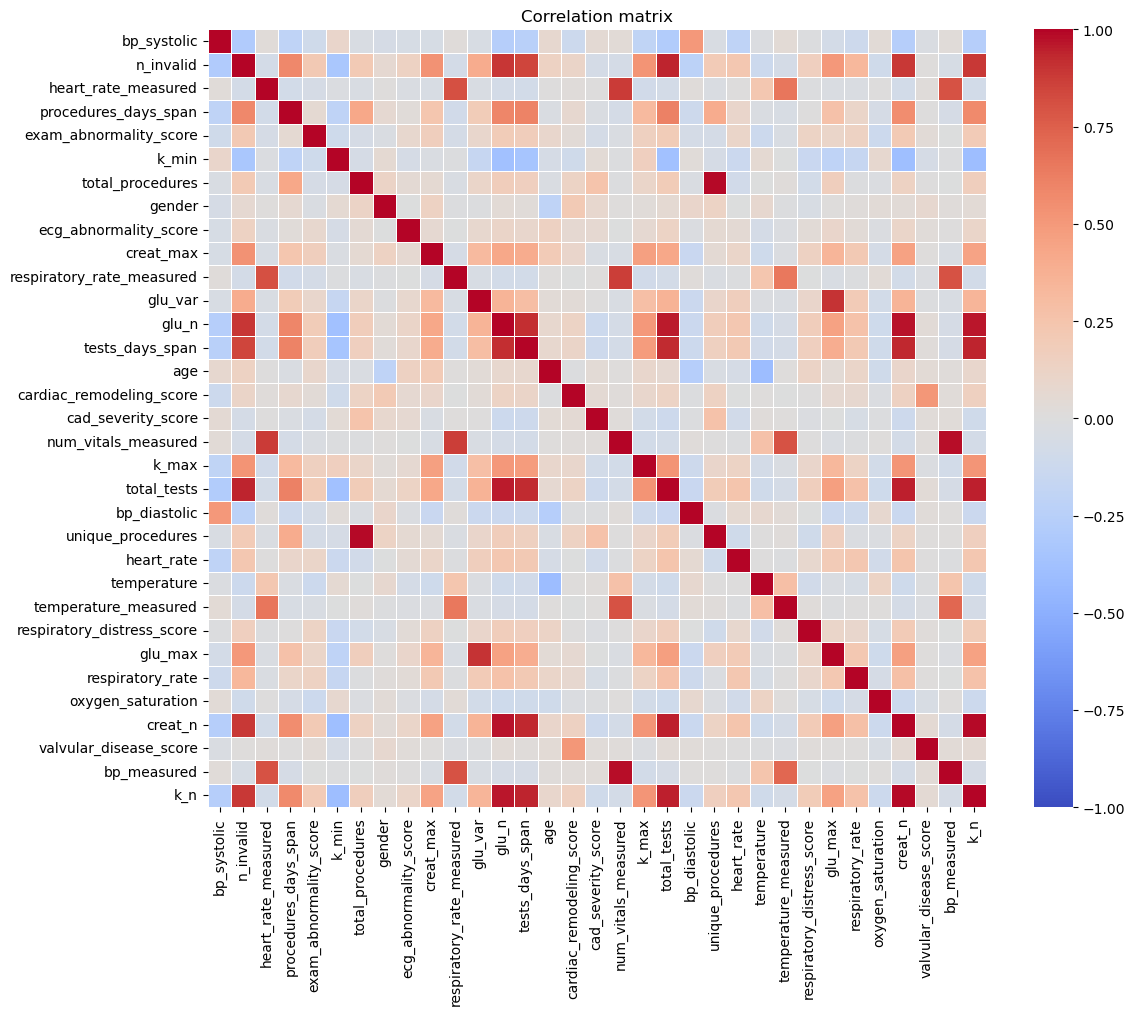

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap base
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=False,  
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()


As we can see, there are lot of redundant features, so we have to choose which ones to keep and which ones to discard.

In [54]:
high_corr = find_high_correlations(corr_matrix, threshold=0.80)
print(f"Highly correlated pairs found (r > 0.80): {len(high_corr)}")

Highly correlated pairs found (r > 0.80): 23


In [55]:
from collections import defaultdict

# protect missingness indicators
protected_features = [col for col in X.columns 
                     if '_measured' in col or col == 'num_vitals_measured' 
                     or col == 'has_vital_monitoring']

corr_groups = defaultdict(set)
for feat1, feat2, corr_val in high_corr.itertuples(index=False):
    group_key = min(feat1, feat2)
    corr_groups[group_key].add(feat1)
    corr_groups[group_key].add(feat2)

features_to_remove = set()

for group_key, group_features in corr_groups.items():
    if len(group_features) <= 1:
        continue
    
    # Check if any protected features in this group
    protected_in_group = [f for f in group_features if f in protected_features]
    
    if protected_in_group:
        # KEEP protected, remove others
        features_to_remove.update([f for f in group_features if f not in protected_features])
    else:
        # Normal behavior: keep highest variance
        variances = {feat: X[feat].var() for feat in group_features if feat in X.columns}
        sorted_by_var = sorted(variances.items(), key=lambda x: x[1], reverse=True)
        keep_feature = sorted_by_var[0][0]
        remove_features = [f for f, _ in sorted_by_var[1:]]
        
        features_to_remove.update(remove_features)
        
        for feat, var in sorted_by_var:
            status = "KEEP" if feat == keep_feature else "REMOVE"
            print(f"   {status:7} {feat:40} (var={var:.3f})")

print(f"Features to remove: {len(features_to_remove)}")
print(f"Final features: {X.shape[1] - len(features_to_remove)}")

# Verify protected features are NOT being removed
removed_protected = [f for f in features_to_remove if f in protected_features]
if removed_protected:
    features_to_remove = features_to_remove - set(removed_protected)

X = X.drop(columns=list(features_to_remove), errors='ignore')


   KEEP    total_tests                              (var=13642.243)
   REMOVE  n_invalid                                (var=2505.161)
   REMOVE  glu_n                                    (var=30.075)
   REMOVE  k_n                                      (var=28.503)
   REMOVE  creat_n                                  (var=24.672)
   REMOVE  tests_days_span                          (var=12.195)
   KEEP    total_procedures                         (var=5.185)
   REMOVE  unique_procedures                        (var=4.641)
   KEEP    total_tests                              (var=13642.243)
   REMOVE  n_invalid                                (var=2505.161)
   REMOVE  glu_n                                    (var=30.075)
   REMOVE  k_n                                      (var=28.503)
   REMOVE  tests_days_span                          (var=12.195)
   KEEP    total_tests                              (var=13642.243)
   REMOVE  n_invalid                                (var=2505.161)
   REMOVE  k

In [57]:
final_features = X.columns.tolist()
patient_profiles_clean = patient_profiles[final_features].copy()

In [58]:
missing_counts = patient_profiles_clean.isna().sum()
missing_pct = (missing_counts / len(patient_profiles_clean) * 100).round(2)
missing_df = pd.DataFrame({
    'Feature': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Pct': missing_pct.values
}).sort_values('Missing_Pct', ascending=False)

In [59]:
missing_df[missing_df['Missing_Pct'] > 0].shape

(0, 3)

In [60]:
missing_df[missing_df['Missing_Pct'] > 0].head(15)

,Feature,Missing_Count,Missing_Pct


In [63]:
patient_profiles_clean.columns

Index(['bp_systolic', 'heart_rate_measured', 'procedures_days_span',
       'exam_abnormality_score', 'k_min', 'total_procedures', 'gender',
       'ecg_abnormality_score', 'creat_max', 'respiratory_rate_measured',
       'age', 'cardiac_remodeling_score', 'cad_severity_score',
       'num_vitals_measured', 'k_max', 'total_tests', 'bp_diastolic',
       'heart_rate', 'temperature', 'temperature_measured',
       'respiratory_distress_score', 'glu_max', 'respiratory_rate',
       'oxygen_saturation', 'valvular_disease_score', 'bp_measured'],
      dtype='object')

## Final dataset statistics

In [61]:
# === FINAL FEATURE SET VERIFICATION ===
print("\n" + "="*70)
print("FINAL CLUSTERING FEATURES - VERIFICATION")
print("="*70)

# Check missingness indicators
missingness_features = [col for col in X.columns 
                       if '_measured' in col or col == 'num_vitals_measured' 
                       or col == 'has_vital_monitoring']

# Check corresponding vital signs
vital_base_names = ['temperature', 'bp_systolic', 'bp_diastolic', 
                    'heart_rate', 'respiratory_rate', 'oxygen_saturation']

vital_values = [col for col in X.columns if any(v in col for v in vital_base_names)
                and '_measured' not in col]

print(f"\n VITAL SIGNS VALUES ({len(vital_values)} features):")
for v in sorted(vital_values):
    print(f"   • {v}")

print(f"\n MISSINGNESS INDICATORS ({len(missingness_features)} features) [INFORMATIVE]:")
for m in sorted(missingness_features):
    n_missing = (patient_profiles[m] == 1).sum() if m in patient_profiles.columns else 'N/A'
    print(f"   • {m:35} (flag=1 for {n_missing} patients)")

print(f"\n OTHER FEATURES ({len(X.columns) - len(vital_values) - len(missingness_features)} features):")
other_features = [col for col in X.columns 
                  if col not in vital_values and col not in missingness_features]
for o in sorted(other_features)[:10]:
    print(f"   • {o}")
if len(other_features) > 10:
    print(f"   ... and {len(other_features)-10} more")

print(f"\n{'='*70}")
print(f" TOTAL FEATURES FOR CLUSTERING: {X.shape[1]}")
print(f"  - {len(vital_values)} imputed vital sign values")
print(f"  - {len(missingness_features)} missingness indicators (clinical monitoring level)")
print(f"  - {len(other_features)} other clinical/lab features")
print(f"{'='*70}\n")

# Verify strategy
if len(missingness_features) > 0:
    print(" Strategy implemented correctly:")
    print("  • Vital signs: imputed values capture physiological state")
    print("  • Missingness flags: capture intensity of clinical monitoring")
    print("  • Both types will be used for clustering")
else:
    print(" WARNING: No missingness indicators found!")
    print("   Check if they were accidentally removed during feature selection")



FINAL CLUSTERING FEATURES - VERIFICATION

 VITAL SIGNS VALUES (6 features):
   • bp_diastolic
   • bp_systolic
   • heart_rate
   • oxygen_saturation
   • respiratory_rate
   • temperature

 MISSINGNESS INDICATORS (5 features) [INFORMATIVE]:
   • bp_measured                         (flag=1 for 567 patients)
   • heart_rate_measured                 (flag=1 for 546 patients)
   • num_vitals_measured                 (flag=1 for 92 patients)
   • respiratory_rate_measured           (flag=1 for 520 patients)
   • temperature_measured                (flag=1 for 604 patients)

 OTHER FEATURES (15 features):
   • age
   • cad_severity_score
   • cardiac_remodeling_score
   • creat_max
   • ecg_abnormality_score
   • exam_abnormality_score
   • gender
   • glu_max
   • k_max
   • k_min
   ... and 5 more

 TOTAL FEATURES FOR CLUSTERING: 26
  - 6 imputed vital sign values
  - 5 missingness indicators (clinical monitoring level)
  - 15 other clinical/lab features

 Strategy implemented correctly:

### patient-wise features transformation

Before applying the transformations to the final patient-wise variables, we need to analyze their distribution to better understand what type of trasnformation they need.

We divide the features we have for clinical purposes: 


In [64]:
feature_groups = {
    "Demographics": ["age", "gender"],
    "Hospitalization": ["n_admissions", "procedures_avg"],
    "clinical severity scores": [
        "cardiac_remodeling_score",
        "cad_severity_score",
        "heart_severity_score",
        "ecg_abnormality_score",
        "exam_abnormality_score",
        "respiratory_distress_score",
        "valvular_disease_score",
    ],
    "Vital Signs - Worst": [
        "temperature",  
        "heart_rate",  
        "respiratory_rate",  
        "oxygen_saturation",  
        "bp_systolic",  
        "bp_diastolic",  
    ],
    "Lab Values - Electrolytes": [
        "k_min",  
        "k_max",  
    ],
    "Lab Values - Metabolic": [
        "glu_max",  
        "creat_max", 
    ],
    "Monitoring Completeness": [
        "bp_measured",
        "heart_rate_max_measured",
        "respiratory_rate_max_measured",
        "temperature_max_measured",
        "num_vitals_measured",  
    ],
}

Now we can visualize the distributions of the clinical features groups

/tmp/ipykernel_84544/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


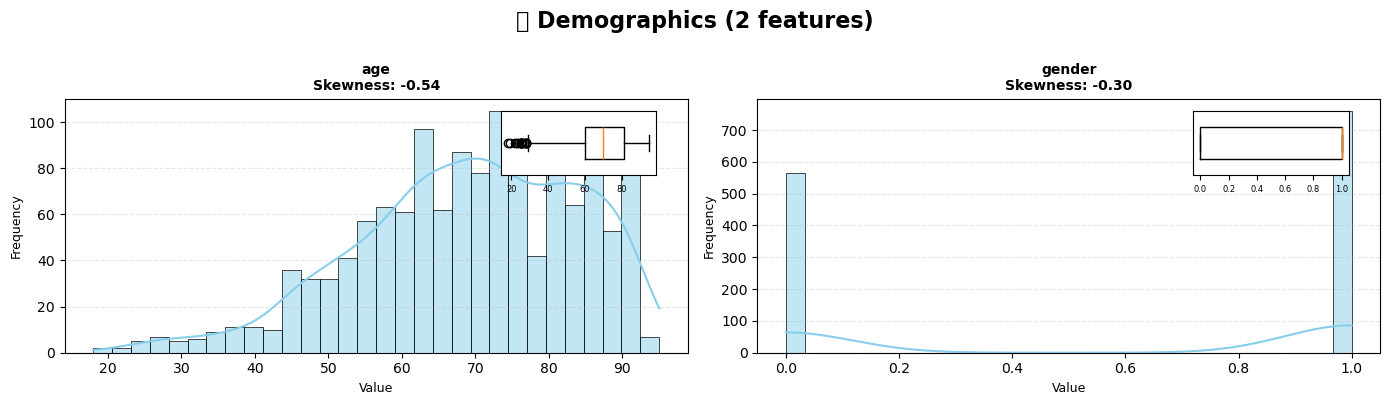


Group: Demographics

age:
  • N values: 1326
  • Range: [18.00, 95.00]
  • Mean: 68.97 ± 15.00
  • Median: 70.00
  • Skewness: -0.54
  • % NaN: 0.0%

gender:
  • N values: 1326
  • Range: [0.00, 1.00]
  • Mean: 0.57 ± 0.49
  • Median: 1.00
  • Skewness: -0.30
  • % NaN: 0.0%




/tmp/ipykernel_84544/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


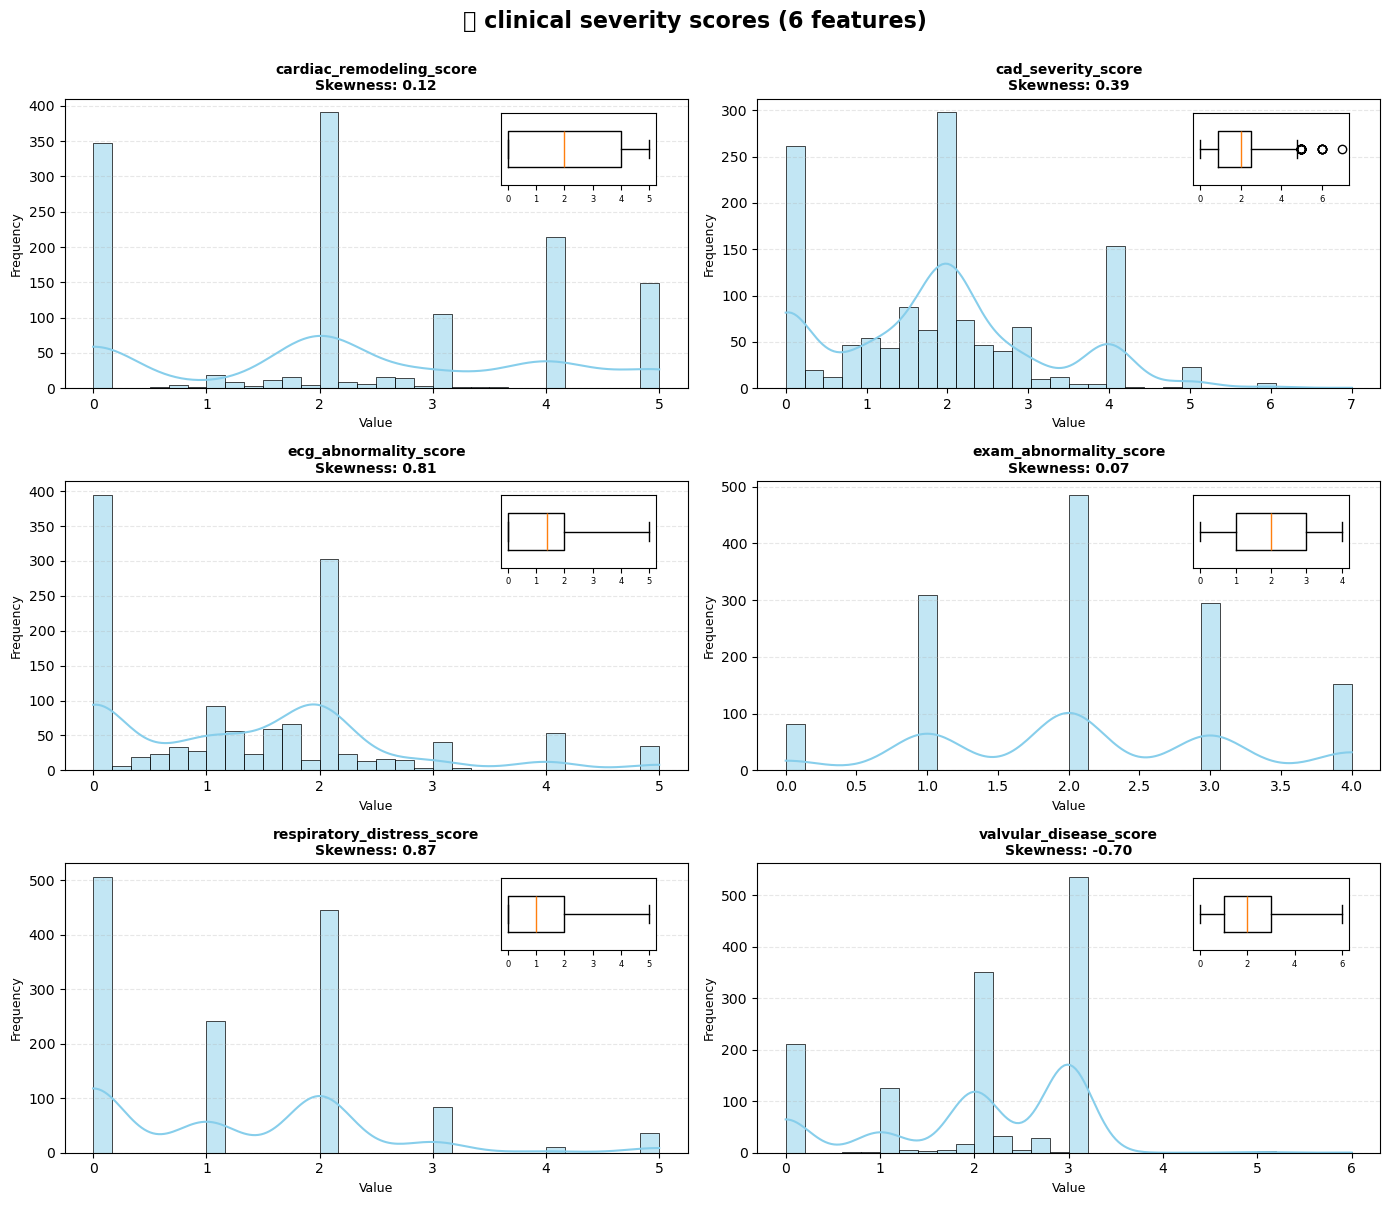


Group: clinical severity scores

cardiac_remodeling_score:
  • N values: 1326
  • Range: [0.00, 5.00]
  • Mean: 2.21 ± 1.67
  • Median: 2.00
  • Skewness: 0.12
  • % NaN: 0.0%

cad_severity_score:
  • N values: 1326
  • Range: [0.00, 7.00]
  • Mean: 1.85 ± 1.33
  • Median: 2.00
  • Skewness: 0.39
  • % NaN: 0.0%

ecg_abnormality_score:
  • N values: 1326
  • Range: [0.00, 5.00]
  • Mean: 1.37 ± 1.23
  • Median: 1.40
  • Skewness: 0.81
  • % NaN: 0.0%

exam_abnormality_score:
  • N values: 1326
  • Range: [0.00, 4.00]
  • Mean: 2.10 ± 1.08
  • Median: 2.00
  • Skewness: 0.07
  • % NaN: 0.0%

respiratory_distress_score:
  • N values: 1326
  • Range: [0.00, 5.00]
  • Mean: 1.22 ± 1.20
  • Median: 1.00
  • Skewness: 0.87
  • % NaN: 0.0%

valvular_disease_score:
  • N values: 1326
  • Range: [0.00, 6.00]
  • Mean: 2.02 ± 1.09
  • Median: 2.00
  • Skewness: -0.70
  • % NaN: 0.0%




/tmp/ipykernel_84544/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


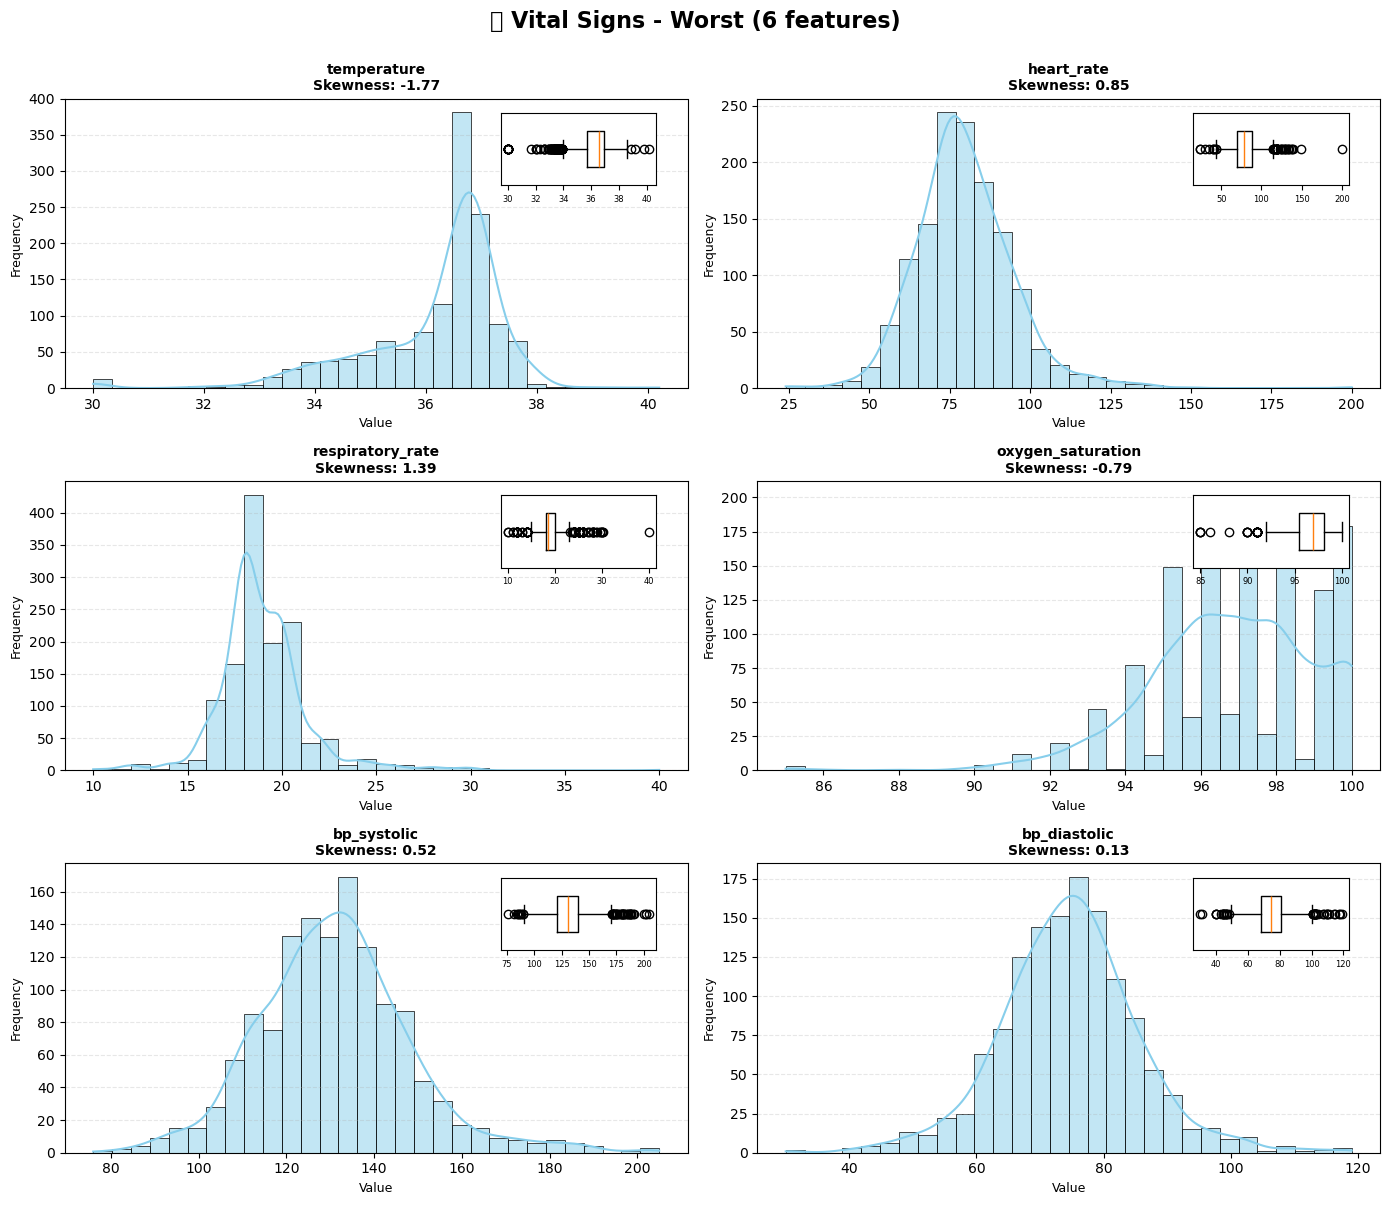


Group: Vital Signs - Worst

temperature:
  • N values: 1326
  • Range: [30.00, 40.20]
  • Mean: 36.18 ± 1.28
  • Median: 36.60
  • Skewness: -1.77
  • % NaN: 0.0%

heart_rate:
  • N values: 1326
  • Range: [24.00, 200.00]
  • Mean: 79.58 ± 15.15
  • Median: 78.10
  • Skewness: 0.85
  • % NaN: 0.0%

respiratory_rate:
  • N values: 1326
  • Range: [10.00, 40.00]
  • Mean: 18.94 ± 2.35
  • Median: 18.60
  • Skewness: 1.39
  • % NaN: 0.0%

oxygen_saturation:
  • N values: 1326
  • Range: [85.00, 100.00]
  • Mean: 96.85 ± 2.20
  • Median: 97.00
  • Skewness: -0.79
  • % NaN: 0.0%

bp_systolic:
  • N values: 1326
  • Range: [76.00, 205.00]
  • Mean: 131.05 ± 17.24
  • Median: 130.90
  • Skewness: 0.52
  • % NaN: 0.0%

bp_diastolic:
  • N values: 1326
  • Range: [30.00, 119.00]
  • Mean: 74.61 ± 10.86
  • Median: 74.70
  • Skewness: 0.13
  • % NaN: 0.0%




/tmp/ipykernel_84544/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


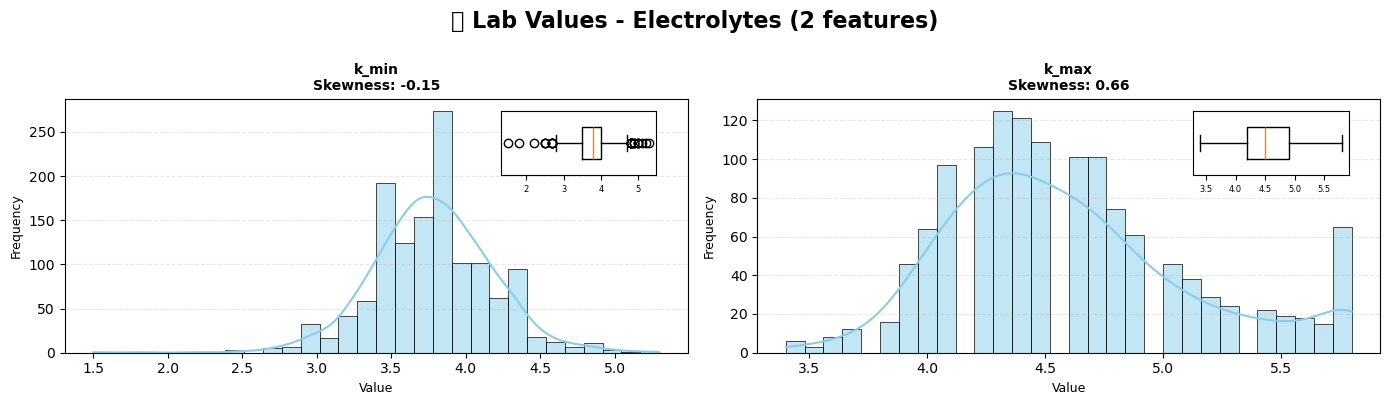


Group: Lab Values - Electrolytes

k_min:
  • N values: 1326
  • Range: [1.50, 5.30]
  • Mean: 3.78 ± 0.40
  • Median: 3.80
  • Skewness: -0.15
  • % NaN: 0.0%

k_max:
  • N values: 1326
  • Range: [3.40, 5.80]
  • Mean: 4.59 ± 0.52
  • Median: 4.50
  • Skewness: 0.66
  • % NaN: 0.0%




/tmp/ipykernel_84544/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


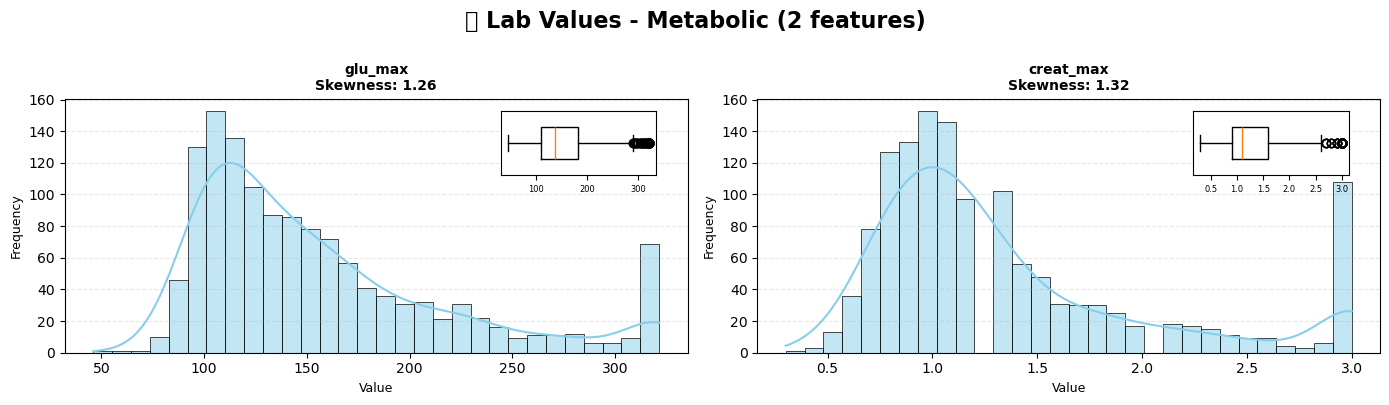


Group: Lab Values - Metabolic

glu_max:
  • N values: 1326
  • Range: [46.00, 321.50]
  • Mean: 155.86 ± 61.94
  • Median: 137.00
  • Skewness: 1.26
  • % NaN: 0.0%

creat_max:
  • N values: 1326
  • Range: [0.30, 3.00]
  • Mean: 1.36 ± 0.66
  • Median: 1.10
  • Skewness: 1.32
  • % NaN: 0.0%




/tmp/ipykernel_84544/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


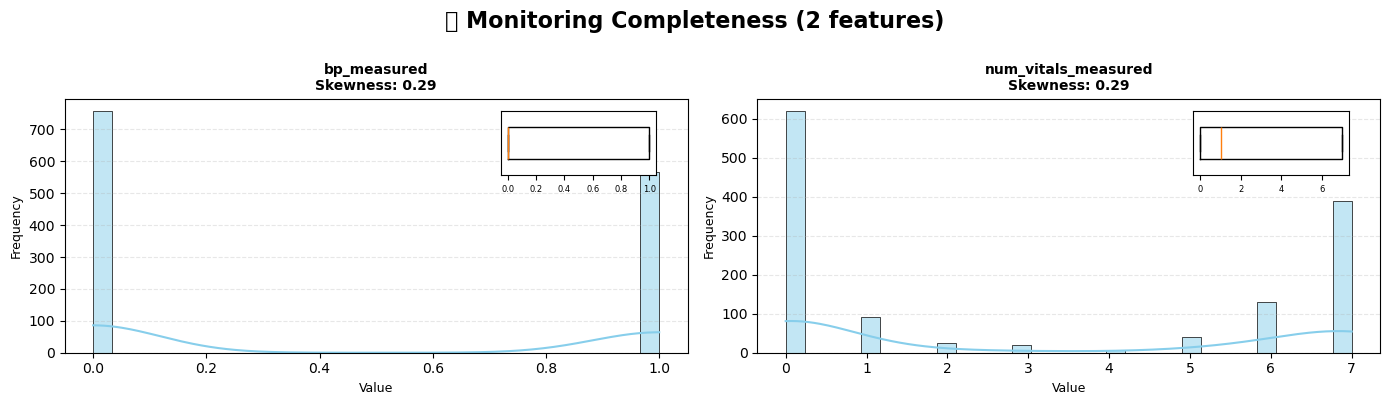


Group: Monitoring Completeness

bp_measured:
  • N values: 1326
  • Range: [0.00, 1.00]
  • Mean: 0.43 ± 0.49
  • Median: 0.00
  • Skewness: 0.29
  • % NaN: 0.0%

num_vitals_measured:
  • N values: 1326
  • Range: [0.00, 7.00]
  • Mean: 2.97 ± 3.20
  • Median: 1.00
  • Skewness: 0.29
  • % NaN: 0.0%




In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

for group_name, features in feature_groups.items():
    existing_features = [f for f in features if f in patient_profiles_clean.columns]
    
    if not existing_features:
        continue
    
    n_cols = 2
    n_rows = (len(existing_features) + 1) // 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    axes = axes.flatten()

    for i, col in enumerate(existing_features):
        ax = axes[i]
        
        data = patient_profiles_clean[col].dropna()
        
        if len(data) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{col}\n(No data)", fontsize=10)
            continue
        
        sns.histplot(data, kde=True, bins=30, ax=ax, color='skyblue', edgecolor='black', linewidth=0.5)
        
        skew_val = skew(data)
        ax_box = ax.inset_axes([0.7, 0.7, 0.25, 0.25])
        ax_box.boxplot(data, vert=False, widths=0.5)
        ax_box.set_yticks([])
        ax_box.set_xlabel('')
        ax_box.tick_params(labelsize=6)
        
        ax.set_title(f"{col}\nSkewness: {skew_val:.2f}", fontsize=10, fontweight='bold')
        ax.set_xlabel('Value', fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Hide unused axes
    for j in range(len(existing_features), len(axes)):
        axes[j].axis('off')
    
    # Main title
    plt.suptitle(f'📊 {group_name} ({len(existing_features)} features)', 
                 fontsize=16, fontweight='bold', y=1.00)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*80}")
    print(f"Group: {group_name}")
    print(f"{'='*80}")
    
    # Print statistics for each feature
    for col in existing_features:
        data = patient_profiles_clean[col].dropna()
        if len(data) > 0:
            print(f"\n{col}:")
            print(f"  • N values: {len(data)}")
            print(f"  • Range: [{data.min():.2f}, {data.max():.2f}]")
            print(f"  • Mean: {data.mean():.2f} ± {data.std():.2f}")
            print(f"  • Median: {data.median():.2f}")
            print(f"  • Skewness: {skew(data):.2f}")
            print(f"  • % NaN: {(patient_profiles_clean[col].isna().sum() / len(patient_profiles_clean) * 100):.1f}%")
    
    print(f"\n{'='*80}\n")


In [67]:
skewness = patient_profiles_clean.skew()
skewed_features = skewness[abs(skewness) > 1].index.tolist()

print(f"Features with skewness > 1: {len(skewed_features)}")
print("\nSkewness per feature:")
print(skewness[abs(skewness) > 1].sort_values(ascending=False))

Features with skewness > 1: 7

Skewness per feature:
procedures_days_span    1.914941
respiratory_rate        1.390638
creat_max               1.323590
total_procedures        1.310143
glu_max                 1.262902
total_tests             1.218263
temperature            -1.775636
dtype: float64


In [68]:
import numpy as np
from scipy.stats import boxcox, yeojohnson
from scipy.stats import skew

def transform_skewed_feature(series, skew_value, method='auto'):
    """
    Advanced feature transformation based on skewness value and data characteristics.
    
    Rules:
    - Skew > 3: Yeo-Johnson (optimal power transformation)
    - 1.5 < Skew <= 3: Box-Cox or sqrt (depends on data range)
    - 1 < Skew <= 1.5: Square root (gentle transformation)
    - |Skew| <= 1: No transformation
    - Skew < -1: Reflect + appropriate transformation
    
    Parameters:
    -----------
    series : pd.Series
        The feature to transform
    skew_value : float
        The skewness value
    method : str
        'auto' (default), 'boxcox', 'yeojohnson', 'sqrt', 'log'
    
    Returns:
    --------
    transformed : pd.Series
        The transformed series
    transformation_name : str
        Description of the transformation applied
    """
    
    transformed = series.copy()
    non_null_mask = transformed.notna()
    non_null_data = transformed[non_null_mask]
    
    if len(non_null_data) == 0:
        return transformed, 'no_transform (all NaN)'
    
    # Calculate data characteristics
    data_min = non_null_data.min()
    data_max = non_null_data.max()
    data_range = data_max - data_min
    has_zeros = (non_null_data == 0).any()
    has_negatives = (non_null_data < 0).any()
    
    
    if skew_value > 1:
        if skew_value > 3 or method == 'yeojohnson':
            try:
                transformed_data, lambda_param = yeojohnson(non_null_data)
                transformed[non_null_mask] = transformed_data
                return transformed, f'yeojohnson (λ={lambda_param:.3f})'
            except:
                pass  # Fallback to next method
        
        if 1.5 < skew_value <= 3:
            if data_max < 100 or method == 'boxcox':
                try:
                    # Handle zeros and negatives for Box-Cox
                    if has_negatives or has_zeros:
                        shift = abs(data_min) + 1
                        data_shifted = non_null_data + shift
                        transformed_data, lambda_param = boxcox(data_shifted)
                        transformed[non_null_mask] = transformed_data
                        return transformed, f'boxcox (λ={lambda_param:.3f}, shift={shift:.2f})'
                    else:
                        transformed_data, lambda_param = boxcox(non_null_data)
                        transformed[non_null_mask] = transformed_data
                        return transformed, f'boxcox (λ={lambda_param:.3f})'
                except:
                    # Fallback to sqrt
                    if has_negatives:
                        shift = abs(data_min) + 1
                        transformed[non_null_mask] = np.sqrt(non_null_data + shift)
                        return transformed, f'sqrt (shifted by {shift:.2f})'
                    else:
                        transformed[non_null_mask] = np.sqrt(non_null_data)
                        return transformed, 'sqrt'
        
        if 1 < skew_value <= 1.5 or method == 'sqrt':
            if has_negatives:
                shift = abs(data_min) + 1
                transformed[non_null_mask] = np.sqrt(non_null_data + shift)
                return transformed, f'sqrt (shifted by {shift:.2f})'
            else:
                transformed[non_null_mask] = np.sqrt(non_null_data)
                return transformed, 'sqrt'
        
        if has_negatives:
            shift = abs(data_min) + 1
            transformed[non_null_mask] = np.log1p(non_null_data + shift)
            return transformed, f'log1p (shifted by {shift:.2f})'
        else:
            transformed[non_null_mask] = np.log1p(non_null_data)
            return transformed, 'log1p'
    
    elif skew_value < -1:
        # Reflect the data
        max_val = non_null_data.max()
        reflected = max_val - non_null_data
        if abs(skew_value) > 3:
            try:
                transformed_data, _ = yeojohnson(reflected)
                transformed[non_null_mask] = transformed_data
                return transformed, 'reflect + yeojohnson'
            except:
                pass
        
        if abs(skew_value) > 1.5:
            transformed[non_null_mask] = np.sqrt(reflected + 1)
            return transformed, 'reflect + sqrt'
        else:
            transformed[non_null_mask] = np.log1p(reflected)
            return transformed, 'reflect + log1p'
    
    else:
        return transformed, 'no_transform (skewness acceptable)'



def transform_all_skewed_features(df, skew_threshold=1.0, exclude_cols=None, method='auto'):
    """
    Apply appropriate transformations to all skewed features in a dataframe.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe with features
    skew_threshold : float
        Minimum skewness to trigger transformation (default: 1.0)
    exclude_cols : list
        Columns to exclude from transformation
    method : str
        Transformation method: 'auto', 'boxcox', 'yeojohnson', 'sqrt', 'log'
    
    Returns:
    --------
    df_transformed : pd.DataFrame
        Dataframe with transformed features
    transformation_info : dict
        Information about transformations applied
    """
    
    if exclude_cols is None:
        exclude_cols = []
    
    df_transformed = df.copy()
    transformation_info = {}
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
    
    for col in numeric_cols:
        data = df[col].dropna()
        
        if len(data) == 0:
            continue
        
        original_skew = skew(data)
        
        if abs(original_skew) > skew_threshold:
            # Apply transformation
            transformed_col, transform_name = transform_skewed_feature(
                df[col], 
                original_skew,
                method=method
            )
            
            # Calculate new skewness
            new_skew = skew(transformed_col.dropna())
            improvement = abs(original_skew) - abs(new_skew)
            
            # Update dataframe
            df_transformed[col] = transformed_col
            
            # Store info
            transformation_info[col] = {
                'method': transform_name,
                'original_skew': original_skew,
                'new_skew': new_skew,
                'improvement': improvement
            }
    
    return df_transformed, transformation_info


In [69]:
df_transformed, info = transform_all_skewed_features(
    patient_profiles_clean,
    skew_threshold=1.0,
    exclude_cols=['subject_id'],
    method='auto'
)

In [70]:
for col, details in info.items():
    print(f"{col}: {details['method']} → improvement: {details['improvement']:.2f}")

procedures_days_span: boxcox (λ=-3.591, shift=1.00) → improvement: 0.85
total_procedures: sqrt → improvement: 0.75
creat_max: sqrt → improvement: 0.37
total_tests: sqrt → improvement: 0.57
temperature: reflect + sqrt → improvement: 0.56
glu_max: sqrt → improvement: 0.32
respiratory_rate: sqrt → improvement: 0.68


We conclude the patient profile creation report by proving that the dataset created is good for clustering by Hopkins score  

In [72]:
from sklearn.neighbors import NearestNeighbors
from random import sample
from numpy.random import uniform
from math import isnan

def hopkins_statistic(X):
    X = X.values  # convert to numpy array
    d = X.shape[1]
    n = len(X)
    m = int(0.1 * n) 
    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
 
    rand_X = sample(range(0, n, 1), m)
 
    ujd = []
    wjd = []
    for j in range(0, m):
        u_dist, _ = nbrs.kneighbors(uniform(np.amin(X,axis=0),np.amax(X,axis=0),d).reshape(1, -1), 2, return_distance=True)
        ujd.append(u_dist[0][1])
        w_dist, _ = nbrs.kneighbors(X[rand_X[j]].reshape(1, -1), 2, return_distance=True)
        wjd.append(w_dist[0][1])
 
    H = sum(ujd) / (sum(ujd) + sum(wjd))
    if isnan(H):
        print(ujd, wjd)
        H = 0
 
    return H

print(f"Hopkins Statistic: {hopkins_statistic(df_transformed)}")


Hopkins Statistic: 0.8207083369575278


In [73]:
# Save the processed dataset
output_path = 'patient_profiles.csv'
df_transformed.to_csv(Path().resolve().parent / 'Features' / output_path, index=False)